In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import gc

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.interpolate import griddata

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"\n{'='*80}\n   1. CONFIGURATION\n{'='*80}")

ORAS5_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

ERA5_FILES = {
    "era5_sst": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\sst.nc"),
    "era5_u10": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\u10_v10.nc"),
    "era5_v10": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\u10_v10.nc"),
    "era5_runoff": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\runoff_full.nc"),
    "era5_d2m": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc"),
    "era5_skt": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc"),
    "era5_stl2": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc"),
    "era5_swvl1": Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc"),
}

ERA5_VAR_NAMES = {
    "era5_sst": "sst",
    "era5_u10": "u10",
    "era5_v10": "v10",
    "era5_runoff": "ro",
    "era5_d2m": "d2m",
    "era5_skt": "skt",
    "era5_stl2": "stl2",
    "era5_swvl1": "swvl1",
}

REGION = {
    "lat_min": 25,
    "lat_max": 45,
    "lon_min": -50,
    "lon_max": -30,
}

FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

MAX_MONTHS = None
LOOKBACK = 12

DLAT = 0.5
DLON = 0.5

ORAS5_VAR_META = {
    "sst": {
        "token": "sst",
        "depth_mode": None,
    },
    "salinity": {
        "token": "so_salinity",
        "depth_mode": "0_100m",
    },
    "thetao": {
        "token": "thetao",
        "depth_mode": "0_100m",
    },
    "qnet": {
        "token": "heat",
        "depth_mode": None,
    },
    "u_current": {
        "token": "u_zonal",
        "depth_mode": "0_100m",
    },
    "v_current": {
        "token": "v_meridional",
        "depth_mode": "0_100m",
    },
}

print("ORAS5 directory:", ORAS5_DIR)
print("ERA5 files:")
for k, v in ERA5_FILES.items():
    print(f"  {k:12s}: {v}")

print("Region:", REGION)
print("ORAS5 variables:", list(ORAS5_VAR_META.keys()))
print("ERA5 variables:", list(ERA5_FILES.keys()))


   1. CONFIGURATION
ORAS5 directory: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED
ERA5 files:
  era5_sst    : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\sst.nc
  era5_u10    : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\u10_v10.nc
  era5_v10    : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\u10_v10.nc
  era5_runoff : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\runoff_full.nc
  era5_d2m    : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
  era5_skt    : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
  era5_stl2   : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
  era5_swvl1  : C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Region: {'lat_min': 25, 'lat_max': 45, 'lon_min': -50, 'lon_max': -30}
ORAS5 variables: ['sst', 'salinity', 'thetao', 'qnet', 'u_current', 'v_current']
ERA5 variables: ['era5_sst', 'era5_u10', 'era5_v10', 'era5_runoff', 

In [2]:
print(f"\n{'='*80}\n   2. CHECK ERA5 FILE CONTENTS\n{'='*80}")

def open_nc(path):
    try:
        return xr.open_dataset(path, engine="h5netcdf")
    except Exception:
        try:
            return xr.open_dataset(path, engine="netcdf4")
        except Exception:
            return xr.open_dataset(path, engine="scipy")

all_paths = set(ERA5_FILES.values())

for path in all_paths:
    print("\n" + "="*80)
    print(path)
    
    with open_nc(path) as ds:
        print(ds)
        print("Data variables:", list(ds.data_vars))
        print("Coordinates:", list(ds.coords))


   2. CHECK ERA5 FILE CONTENTS

C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
<xarray.Dataset> Size: 28GB
Dimensions:     (valid_time: 909, latitude: 451, longitude: 1051)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2025-09-01
  * latitude    (latitude) float64 4kB 65.0 64.9 64.8 64.7 ... 20.2 20.1 20.0
  * longitude   (longitude) float64 8kB -85.0 -84.9 -84.8 ... 19.8 19.9 20.0
    expver      (valid_time) <U4 15kB ...
Data variables: (12/16)
    d2m         (valid_time, latitude, longitude) float32 2GB ...
    t2m         (valid_time, latitude, longitude) float32 2GB ...
    skt         (valid_time, latitude, longitude) float32 2GB ...
    stl1        (valid_time, latitude, longitude) float32 2GB ...
    stl2        (valid_time, latitude, longitude) float32 2GB ...
    stl3        (valid_time, latitude, longitude) float32 2GB ...
    ...          ...
    swvl3       (valid_time, latitude, longitude) 

In [5]:
print(f"\n{'='*80}\n   3. HELPER FUNCTIONS\n{'='*80}")

def files_for_token(data_dir, token):
    all_nc = sorted(data_dir.rglob("*.nc"))
    out = [p for p in all_nc if FILE_RE.search(p.name) and token in p.name]
    return sorted(out)


def time_from_filename(path):
    m = FILE_RE.search(path.name)
    if m is None:
        raise ValueError(f"Filename does not match expected pattern: {path.name}")

    year = int(m.group(1))
    month = int(m.group(2))

    return pd.Timestamp(year=year, month=month, day=1)


def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev",
        "bnds", "bounds", "nbnds", "nv"
    }

    candidates = [k for k in ds.data_vars if k not in ignore]

    if len(candidates) == 0:
        raise ValueError(f"No usable variable found. Available data_vars={list(ds.data_vars)}")

    return candidates[0]


def find_coord_name(ds, options):
    for name in options:
        if name in ds.coords or name in ds.variables:
            return name
    return None


def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)


def subset_region(ds, region):
    lat_name = find_coord_name(ds, ["lat", "latitude", "nav_lat"])
    lon_name = find_coord_name(ds, ["lon", "longitude", "nav_lon"])

    if lat_name is None or lon_name is None:
        print("Warning: could not find lat/lon coords; skipping regional subset")
        return ds

    lat = ds[lat_name]
    lon = normalise_longitude(ds[lon_name])

    if lon_name in ds.coords:
        ds = ds.assign_coords({lon_name: lon})

    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )

    return ds.where(mask, drop=True)


def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ["depth", "deptht", "depthu", "depthv", "nav_lev"]:
        if zname in da.dims:
            if zname in da.coords:
                z = da[zname]
            elif zname in ds.coords:
                z = ds[zname]
            elif zname in ds.variables:
                z = ds[zname]
            else:
                z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname])

            if depth_mode == "0_100m":
                return da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)

    return da


def clean_array(da):
    for tdim in ["time_counter", "valid_time", "nav_time", "time"]:
        if tdim in da.dims and da.sizes[tdim] == 1:
            da = da.isel({tdim: 0}, drop=True)

    for bdim in ["bnds", "bounds", "nbnds", "nv"]:
        if bdim in da.dims:
            da = da.isel({bdim: 0}, drop=True)

    da = da.squeeze(drop=True)

    if "y" in da.dims and "x" in da.dims:
        da = da.transpose("y", "x")

    return da.astype(np.float32)


def regrid_oras5_to_regular(da, ds, region, dlat=0.5, dlon=0.5):
    # Try to get ORAS5 curvilinear coordinates from either da or ds
    if "nav_lat" in da.coords:
        nav_lat = da["nav_lat"].values
    elif "nav_lat" in ds:
        nav_lat = ds["nav_lat"].values
    else:
        raise ValueError("No nav_lat found in this file")

    if "nav_lon" in da.coords:
        nav_lon = da["nav_lon"].values
    elif "nav_lon" in ds:
        nav_lon = ds["nav_lon"].values
    else:
        raise ValueError("No nav_lon found in this file")

    nav_lon = np.where(nav_lon > 180, nav_lon - 360, nav_lon)

    values = np.squeeze(da.values)

    if values.shape != nav_lat.shape:
        raise ValueError(
            f"Shape mismatch. values={values.shape}, nav_lat={nav_lat.shape}. "
            f"File may be on a different grid or not an ORAS5 spatial file."
        )

    valid = (
        np.isfinite(nav_lat) &
        np.isfinite(nav_lon) &
        np.isfinite(values)
    )

    points = np.column_stack([nav_lon[valid], nav_lat[valid]])

    target_lons = np.arange(region["lon_min"], region["lon_max"] + dlon, dlon)
    target_lats = np.arange(region["lat_min"], region["lat_max"] + dlat, dlat)

    lon2d, lat2d = np.meshgrid(target_lons, target_lats)

    linear = griddata(points, values[valid], (lon2d, lat2d), method="linear")
    nearest = griddata(points, values[valid], (lon2d, lat2d), method="nearest")

    regridded = np.where(np.isfinite(linear), linear, nearest)

    return xr.DataArray(
        regridded.astype(np.float32),
        dims=("lat", "lon"),
        coords={"lat": target_lats, "lon": target_lons},
        name=da.name
    )


def standardise_era5_time(ds):
    rename_dict = {}

    if "valid_time" in ds.coords:
        rename_dict["valid_time"] = "time"
    elif "time_counter" in ds.coords:
        rename_dict["time_counter"] = "time"

    if rename_dict:
        ds = ds.rename(rename_dict)

    if "time" not in ds.coords:
        raise ValueError(f"No time coordinate found. Available coords: {list(ds.coords)}")

    ds["time"] = pd.to_datetime(ds["time"].values)

    return ds


def load_era5_variable(path, var_name, feature_name, region):
    with open_nc(path) as ds:
        ds = standardise_era5_time(ds)

        rename_dict = {}
        if "latitude" in ds.coords:
            rename_dict["latitude"] = "lat"
        if "longitude" in ds.coords:
            rename_dict["longitude"] = "lon"
        ds = ds.rename(rename_dict)

        if var_name not in ds.data_vars:
            raise ValueError(
                f"Variable '{var_name}' not found in {path.name}. "
                f"Available variables: {list(ds.data_vars)}"
            )

        da = ds[var_name]

        if "lon" in da.coords:
            da = da.assign_coords(lon=normalise_longitude(da["lon"]))
            da = da.sortby("lon")

        if "lat" in da.coords:
            da = da.sortby("lat")

        # Subset before monthly averaging to avoid memory crash
        da = da.sel(
            lat=slice(region["lat_min"], region["lat_max"]),
            lon=slice(region["lon_min"], region["lon_max"])
        )

        for dim in list(da.dims):
            if dim not in ["time", "lat", "lon"]:
                da = da.isel({dim: 0}, drop=True)

        # Now monthly mean only for the small regional variable
        da = da.resample(time="MS").mean()

        # ERA5 temperatures are usually Kelvin
        if feature_name in ["era5_sst", "era5_d2m", "era5_skt", "era5_stl2"]:
            da = da - 273.15

        target_lats = np.arange(region["lat_min"], region["lat_max"] + DLAT, DLAT)
        target_lons = np.arange(region["lon_min"], region["lon_max"] + DLON, DLON)

        da = da.interp(lat=target_lats, lon=target_lons)

        da = da.astype(np.float32)
        da.name = feature_name

        return da.load()


print("Helper functions ready.")


   3. HELPER FUNCTIONS
Helper functions ready.


In [7]:
print(f"\n{'='*80}\n   4. LOADING AND REGRIDDING ORAS5 VARIABLES\n{'='*80}")

file_dict = {}

for var_name, meta in ORAS5_VAR_META.items():
    paths = files_for_token(ORAS5_DIR, meta["token"])
    file_dict[var_name] = {time_from_filename(p): p for p in paths}
    print(f"{var_name:12s}: {len(paths)} files")

common_oras5_times = sorted(set.intersection(*[set(d.keys()) for d in file_dict.values()]))

if MAX_MONTHS is not None:
    common_oras5_times = common_oras5_times[:MAX_MONTHS]

print(f"\nCommon ORAS5 monthly timesteps: {len(common_oras5_times)}")
print(f"First: {common_oras5_times[0]}")
print(f"Last : {common_oras5_times[-1]}")

monthly_fields = []
used_times = []

for i, ts in enumerate(common_oras5_times, start=1):
    print(f"Loading {i}/{len(common_oras5_times)}: {ts.strftime('%Y-%m')}")

    var_arrays = []

    for var_name, meta in ORAS5_VAR_META.items():
        path = file_dict[var_name][ts]

        with open_nc(path) as ds:
            ds = subset_region(ds, REGION)
            vname = find_main_var(ds)

            da = ds[vname]
            da = depth_reduce_if_needed(da, ds, meta["depth_mode"])
            da = clean_array(da)

            try:
                da = regrid_oras5_to_regular(
                    da,
                    ds,
                    REGION,
                    dlat=DLAT,
                    dlon=DLON
                )
            except ValueError as e:
                print(f"Skipping {path.name}: {e}")
                continue

            da.name = var_name
            var_arrays.append(da.load())

    if len(var_arrays) != len(ORAS5_VAR_META):
        print(f"Skipping whole month {ts.strftime('%Y-%m')} because one or more variables failed")
        continue

    stacked = xr.concat(var_arrays, dim="feature")
    stacked = stacked.assign_coords(feature=list(ORAS5_VAR_META.keys()))
    stacked = stacked.expand_dims(time=[np.datetime64(ts)])

    monthly_fields.append(stacked)
    used_times.append(ts)

oras5_monthly = xr.concat(
    monthly_fields,
    dim="time",
    coords="minimal",
    compat="override",
    join="override"
)

oras5_monthly.name = "oras5_regular_multivar"

print("\nFinal ORAS5 monthly tensor:")
print(oras5_monthly)
print("Shape:", oras5_monthly.shape)

print("\nAvailable date range for each variable:\n")

for var_name, d in file_dict.items():
    times = sorted(d.keys())
    print(
        f"{var_name:12s} "
        f"{times[0].strftime('%Y-%m')}  ->  "
        f"{times[-1].strftime('%Y-%m')}   "
        f"({len(times)} files)"
    )


   4. LOADING AND REGRIDDING ORAS5 VARIABLES
sst         : 790 files
salinity    : 790 files
thetao      : 790 files
qnet        : 791 files
u_current   : 790 files
v_current   : 790 files

Common ORAS5 monthly timesteps: 790
First: 1958-01-01 00:00:00
Last : 2025-04-01 00:00:00
Loading 1/790: 1958-01
Loading 2/790: 1958-02
Loading 3/790: 1958-03
Loading 4/790: 1958-04
Loading 5/790: 1958-05
Loading 6/790: 1958-06
Loading 7/790: 1958-07
Loading 8/790: 1958-08
Loading 9/790: 1958-09
Loading 10/790: 1958-10
Loading 11/790: 1958-11
Loading 12/790: 1958-12
Loading 13/790: 1959-01
Loading 14/790: 1959-02
Loading 15/790: 1959-03
Loading 16/790: 1959-04
Loading 17/790: 1959-05
Loading 18/790: 1959-06
Loading 19/790: 1959-07
Loading 20/790: 1959-08
Loading 21/790: 1959-09
Loading 22/790: 1959-10
Loading 23/790: 1959-11
Loading 24/790: 1959-12
Loading 25/790: 1960-01
Loading 26/790: 1960-02
Loading 27/790: 1960-03
Loading 28/790: 1960-04
Loading 29/790: 1960-05
Loading 30/790: 1960-06
Loading 

In [8]:
print("\nAvailable date range for each variable:\n")

for var_name, d in file_dict.items():
    times = sorted(d.keys())
    print(
        f"{var_name:12s} "
        f"{times[0].strftime('%Y-%m')}  ->  "
        f"{times[-1].strftime('%Y-%m')}   "
        f"({len(times)} files)"
    )


Available date range for each variable:

sst          1958-01  ->  2025-04   (790 files)
salinity     1958-01  ->  2025-04   (790 files)
thetao       1958-01  ->  2025-04   (790 files)
qnet         1958-01  ->  2025-05   (791 files)
u_current    1958-01  ->  2025-04   (790 files)
v_current    1958-01  ->  2025-04   (790 files)


In [9]:
era5_arrays = []

for feature_name, path in ERA5_FILES.items():
    var_name = ERA5_VAR_NAMES[feature_name]

    print(f"Loading {feature_name:12s} from {path.name} using variable '{var_name}'")

    da = load_era5_variable(
        path=path,
        var_name=var_name,
        feature_name=feature_name,
        region=REGION
    )

    era5_arrays.append(da)

era5_monthly = xr.concat(era5_arrays, dim="feature")
era5_monthly = era5_monthly.assign_coords(feature=list(ERA5_FILES.keys()))
era5_monthly.name = "era5_regular_multivar"

print(era5_monthly)

Loading era5_sst     from sst.nc using variable 'sst'
Loading era5_u10     from u10_v10.nc using variable 'u10'
Loading era5_v10     from u10_v10.nc using variable 'v10'
Loading era5_runoff  from runoff_full.nc using variable 'ro'
Loading era5_d2m     from all_others.nc using variable 'd2m'
Loading era5_skt     from all_others.nc using variable 'skt'
Loading era5_stl2    from all_others.nc using variable 'stl2'
Loading era5_swvl1   from all_others.nc using variable 'swvl1'
<xarray.DataArray 'era5_regular_multivar' (feature: 8, time: 1036, lat: 41,
                                           lon: 41)> Size: 56MB
array([[[[24.21988   , 24.162262  , 24.131989  , ..., 23.046051  ,
          22.963043  , 22.792145  ],
         [23.915192  , 23.887848  , 23.878082  , ..., 22.790192  ,
          22.70816   , 22.541168  ],
         [23.681793  , 23.649567  , 23.585114  , ..., 22.474762  ,
          22.369293  , 22.27359   ],
         ...,
         [ 3.0314026 ,  2.6456604 ,  3.7550354 , ..., 15

In [10]:
print(f"\n{'='*80}\n   6. COMBINING ORAS5 AND ERA5\n{'='*80}")

common_times = np.intersect1d(
    oras5_monthly.time.values,
    era5_monthly.time.values
)

if MAX_MONTHS is not None:
    common_times = common_times[:MAX_MONTHS]

oras5_aligned = oras5_monthly.sel(time=common_times)
era5_aligned = era5_monthly.sel(time=common_times)

combined_monthly = xr.concat(
    [oras5_aligned, era5_aligned],
    dim="feature"
)

combined_monthly.name = "oras5_era5_regular_multivar"

print("\nCombined monthly tensor:")
print(combined_monthly)
print("Shape:", combined_monthly.shape)
print("Features:", list(combined_monthly.feature.values))
print("First time:", pd.to_datetime(combined_monthly.time.values[0]))
print("Last time :", pd.to_datetime(combined_monthly.time.values[-1]))


   6. COMBINING ORAS5 AND ERA5

Combined monthly tensor:
<xarray.DataArray 'oras5_era5_regular_multivar' (time: 789, feature: 14,
                                                 lat: 41, lon: 41)> Size: 74MB
array([[[[ 2.34535007e+01,  2.34274025e+01,  2.33011227e+01, ...,
           2.19593220e+01,  2.19441223e+01,  2.19552135e+01],
         [ 2.32515965e+01,  2.32798328e+01,  2.31490097e+01, ...,
           2.18421974e+01,  2.18343105e+01,  2.18087788e+01],
         [ 2.29975491e+01,  2.30007381e+01,  2.28932953e+01, ...,
           2.16560059e+01,  2.16852074e+01,  2.17302227e+01],
         ...,
         [ 3.89797068e+00,  3.54310250e+00,  3.41622806e+00, ...,
           1.45103941e+01,  1.44450855e+01,  1.41834641e+01],
         [ 3.76289463e+00,  3.35775614e+00,  2.87952423e+00, ...,
           1.43481550e+01,  1.42319508e+01,  1.40287981e+01],
         [ 3.30363441e+00,  2.83539081e+00,  2.38007593e+00, ...,
           1.40816822e+01,  1.41599112e+01,  1.40435486e+01]],

      

In [11]:
print(f"\n{'='*80}\n   7. DATE-BASED SCALING AND SEQUENCE GENERATION\n{'='*80}")

combined_monthly = combined_monthly.sortby("time")

LOOKBACK = 12

TRAIN_END = pd.Timestamp("1981-12-01")
FORECAST_START = pd.Timestamp("1982-01-01")
FORECAST_END = pd.Timestamp("1986-12-01")

times = pd.to_datetime(combined_monthly.time.values)

data = combined_monthly.transpose("time", "lat", "lon", "feature").values.astype(np.float32)
data[np.abs(data) > 1e10] = np.nan

train_time_mask = times <= TRAIN_END

means = np.nanmean(data[train_time_mask], axis=(0, 1, 2), keepdims=True)
stds = np.nanstd(data[train_time_mask], axis=(0, 1, 2), keepdims=True)

data_scaled = (data - means) / (stds + 1e-8)
data_scaled = np.nan_to_num(data_scaled, nan=0.0, posinf=0.0, neginf=0.0)

scaler = {
    "means": means,
    "stds": stds,
    "features": list(combined_monthly.feature.values)
}

def is_consecutive_month_block(time_block):
    expected = pd.date_range(time_block[0], periods=len(time_block), freq="MS")
    return np.array_equal(pd.to_datetime(time_block).values, expected.values)

X, y, target_times = [], [], []

for i in range(data_scaled.shape[0] - LOOKBACK):
    block_times = times[i:i+LOOKBACK+1]
    target_time = times[i+LOOKBACK]

    # Do not allow sequences to cross missing-month gaps
    if not is_consecutive_month_block(block_times):
        continue

    # Only train/validate using targets up to Dec 1981
    if target_time <= TRAIN_END:
        X.append(data_scaled[i:i+LOOKBACK])
        y.append(data_scaled[i+LOOKBACK])
        target_times.append(target_time)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
target_times = pd.to_datetime(target_times)

# Validation from final few years before 1982
VAL_START = pd.Timestamp("1977-01-01")

train_mask = target_times < VAL_START
val_mask = (target_times >= VAL_START) & (target_times <= TRAIN_END)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

train_times = target_times[train_mask]
val_times = target_times[val_mask]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print(f"TRAIN: {train_times[0]} to {train_times[-1]}")
print(f"VAL  : {val_times[0]} to {val_times[-1]}")


   7. DATE-BASED SCALING AND SEQUENCE GENERATION
X_train: (216, 12, 41, 41, 14)
y_train: (216, 41, 41, 14)
X_val  : (47, 12, 41, 41, 14)
y_val  : (47, 41, 41, 14)
TRAIN: 1959-01-01 00:00:00 to 1976-12-01 00:00:00
VAL  : 1977-01-01 00:00:00 to 1981-12-01 00:00:00


In [12]:
print(f"\n{'='*80}\n   8. TRAINING ORAS5 + ERA5 CONVLSTM\n{'='*80}")

_, time_steps, n_lat, n_lon, n_features = X_train.shape

model = Sequential([
    ConvLSTM2D(
        16,
        (3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(time_steps, n_lat, n_lon, n_features)
    ),
    BatchNormalization(),

    ConvLSTM2D(
        16,
        (3, 3),
        padding="same",
        return_sequences=False
    ),
    BatchNormalization(),

    Conv2D(
        n_features,
        (3, 3),
        activation="linear",
        padding="same"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_oras5_era5_regular_convlstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")


   8. TRAINING ORAS5 + ERA5 CONVLSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 41, 41, 16)      │          17,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 41, 41, 16)      │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 41, 41, 16)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 41, 41, 14)          │           2,030 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,998 (148.43 KB)

 Trainable params: 37,934 (148.18 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 236ms/step - loss: 0.4229 - mae: 0.3999 - val_loss: 0.3237 - val_mae: 0.3057 - learning_rate: 0.0010
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - loss: 0.1964 - mae: 0.2372 - val_loss: 0.2842 - val_mae: 0.2801 - learning_rate: 0.0010
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - loss: 0.1586 - mae: 0.2106 - val_loss: 0.2560 - val_mae: 0.2686 - learning_rate: 0.0010
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - loss: 0.1454 - mae: 0.2019 - val_loss: 0.2301 - val_mae: 0.2607 - learning_rate: 0.0010
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - loss: 0.1346 - mae: 0.1899 - val_loss: 0.1863 - val_mae: 0.2371 - learning_rate: 0.0010
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - loss: 0.1256 - mae: 0.1799 - val_loss: 0.1550 - val_mae: 0.2138 - learning_rate: 0.0010
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 232ms/step - loss: 0.1177 - mae: 0.1713 - val_loss: 0.1349 - val_mae: 0.1927 - learning_rate: 0.0010


   9. TRAINING HISTORY


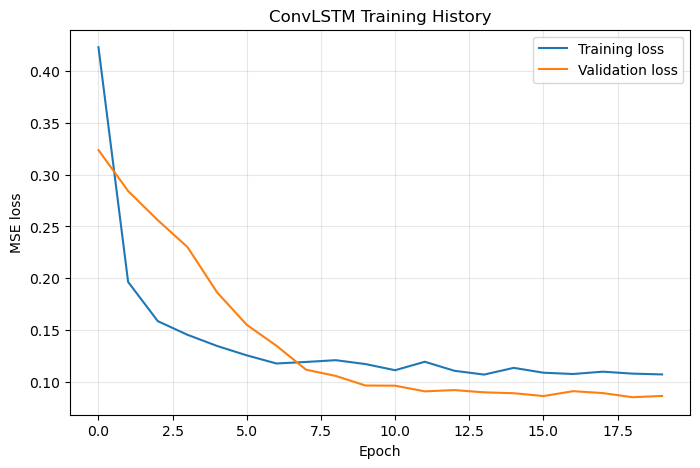

In [13]:
print(f"\n{'='*80}\n   9. TRAINING HISTORY\n{'='*80}")

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("ConvLSTM Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
print(f"\n{'='*80}\n   10. RECURSIVE 5-YEAR FORECAST: 1982–1986\n{'='*80}")

model = load_model("best_oras5_era5_regular_convlstm.keras")

forecast_months = pd.date_range("1982-01-01", "1986-12-01", freq="MS")

# Seed with the final 12 real months before the forecast period
seed_start = pd.Timestamp("1981-01-01")
seed_end = pd.Timestamp("1981-12-01")

seed_mask = (times >= seed_start) & (times <= seed_end)

seed = data_scaled[seed_mask]

if seed.shape[0] != LOOKBACK:
    raise ValueError(
        f"Expected {LOOKBACK} seed months from Jan-Dec 1981, "
        f"but found {seed.shape[0]} months."
    )

current_sequence = seed.copy()

forecast_scaled = []

for forecast_time in forecast_months:
    X_input = current_sequence[np.newaxis, ...]
    next_pred = model.predict(X_input, verbose=0)[0]

    forecast_scaled.append(next_pred)

    # Roll sequence forward: drop oldest month, append prediction
    current_sequence = np.concatenate(
        [current_sequence[1:], next_pred[np.newaxis, ...]],
        axis=0
    )

forecast_scaled = np.array(forecast_scaled, dtype=np.float32)

forecast_unscaled = (forecast_scaled * scaler["stds"]) + scaler["means"]

print("Forecast shape:", forecast_unscaled.shape)
print("Forecast months:", forecast_months[0], "to", forecast_months[-1])


   10. RECURSIVE 5-YEAR FORECAST: 1982–1986
Forecast shape: (60, 41, 41, 14)
Forecast months: 1982-01-01 00:00:00 to 1986-12-01 00:00:00


In [15]:
print(f"\n{'='*80}\n   11. FORECAST EVALUATION: 1982–1986\n{'='*80}")

truth_mask = (times >= FORECAST_START) & (times <= FORECAST_END)

truth_unscaled = data[truth_mask]
truth_times = times[truth_mask]

results = []

for i, feature in enumerate(scaler["features"]):
    truth = truth_unscaled[..., i].flatten()
    pred = forecast_unscaled[..., i].flatten()

    mask = np.isfinite(truth) & np.isfinite(pred)

    if mask.sum() == 0:
        results.append({
            "feature": feature,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "n_valid": 0
        })
        continue

    mae = mean_absolute_error(truth[mask], pred[mask])
    rmse = np.sqrt(mean_squared_error(truth[mask], pred[mask]))
    r2 = r2_score(truth[mask], pred[mask])

    results.append({
        "feature": feature,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_valid": int(mask.sum())
    })

results_df = pd.DataFrame(results)
results_df


   11. FORECAST EVALUATION: 1982–1986


,feature,MAE,RMSE,R2,n_valid
0,sst,3.451747,4.838854,-0.448115,100860
1,salinity,0.595225,0.860748,-0.704477,100860
2,thetao,2.880638,4.122399,-0.297935,100860
3,qnet,298.717590,504.202666,-7.708386,100860
4,u_current,0.148031,0.195139,-4.440059,100860
5,v_current,0.131303,0.193309,-4.997006,100860
6,era5_sst,3.661595,5.139493,-0.555832,100860
7,era5_u10,NaN,NaN,NaN,0
8,era5_v10,NaN,NaN,NaN,0
9,era5_runoff,0.000000,0.000000,1.000000,100860



   12. ANNUAL MAPS: ACTUAL vs FORECAST vs ABSOLUTE DIFFERENCE


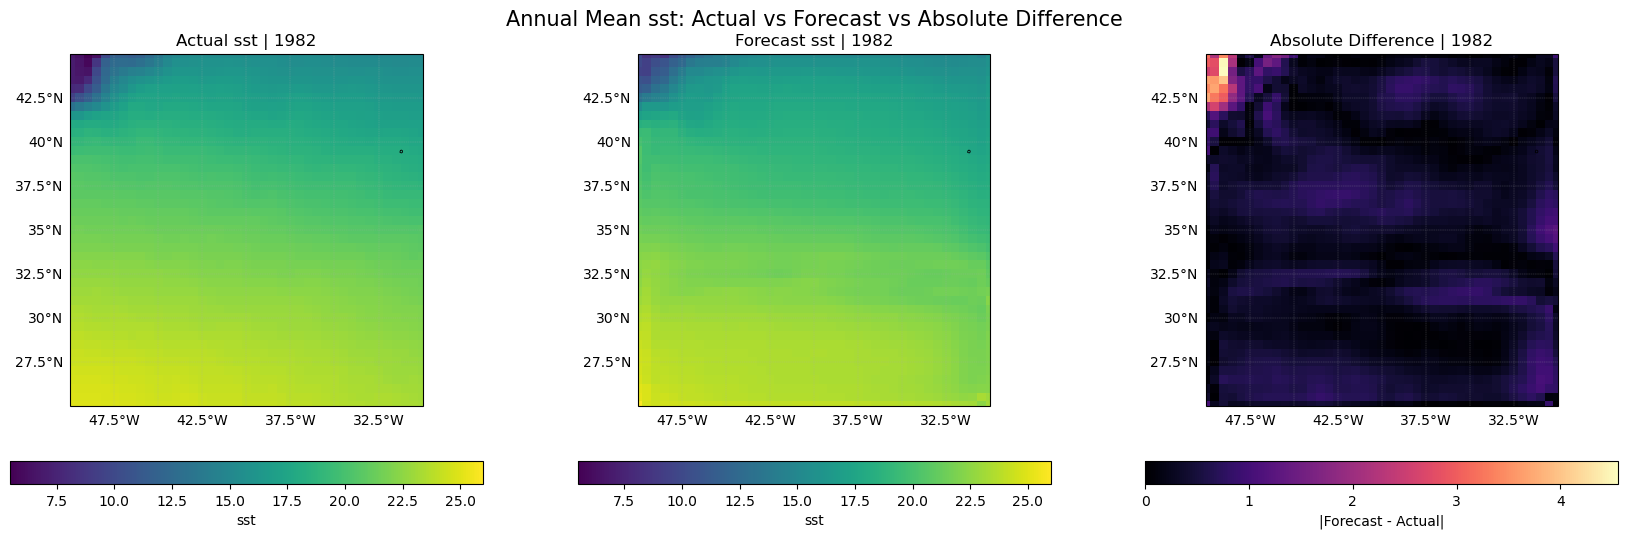

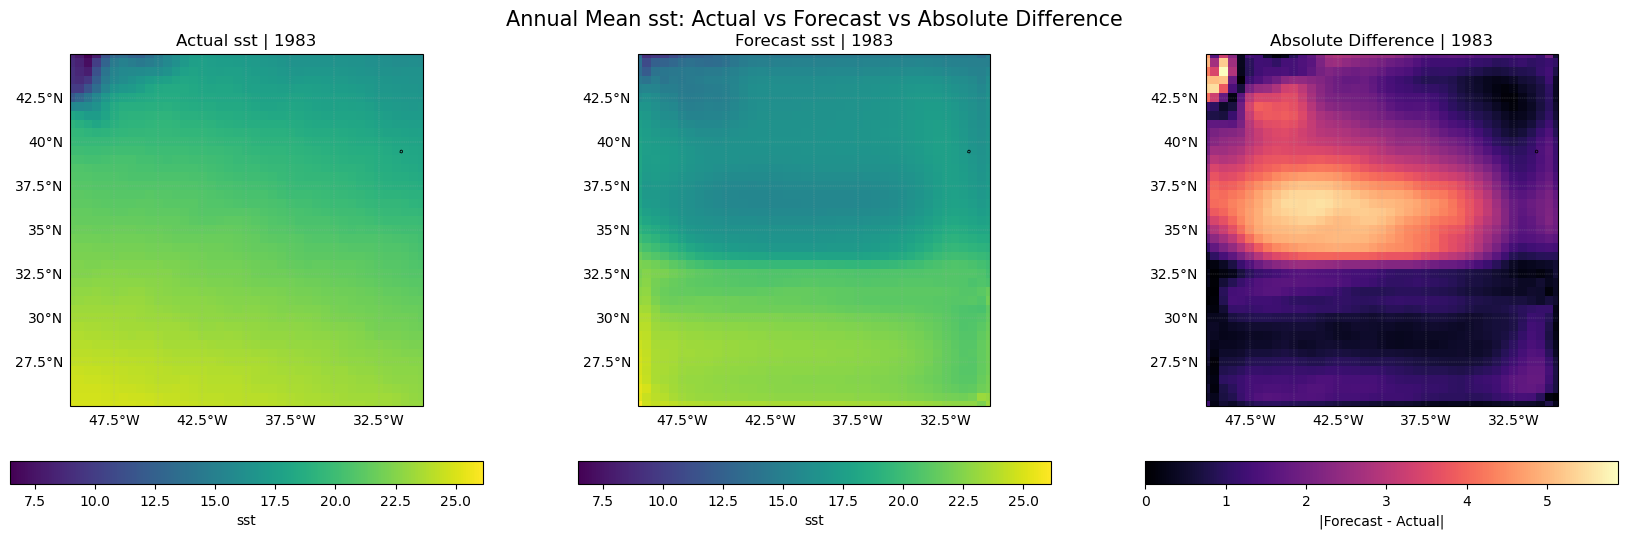

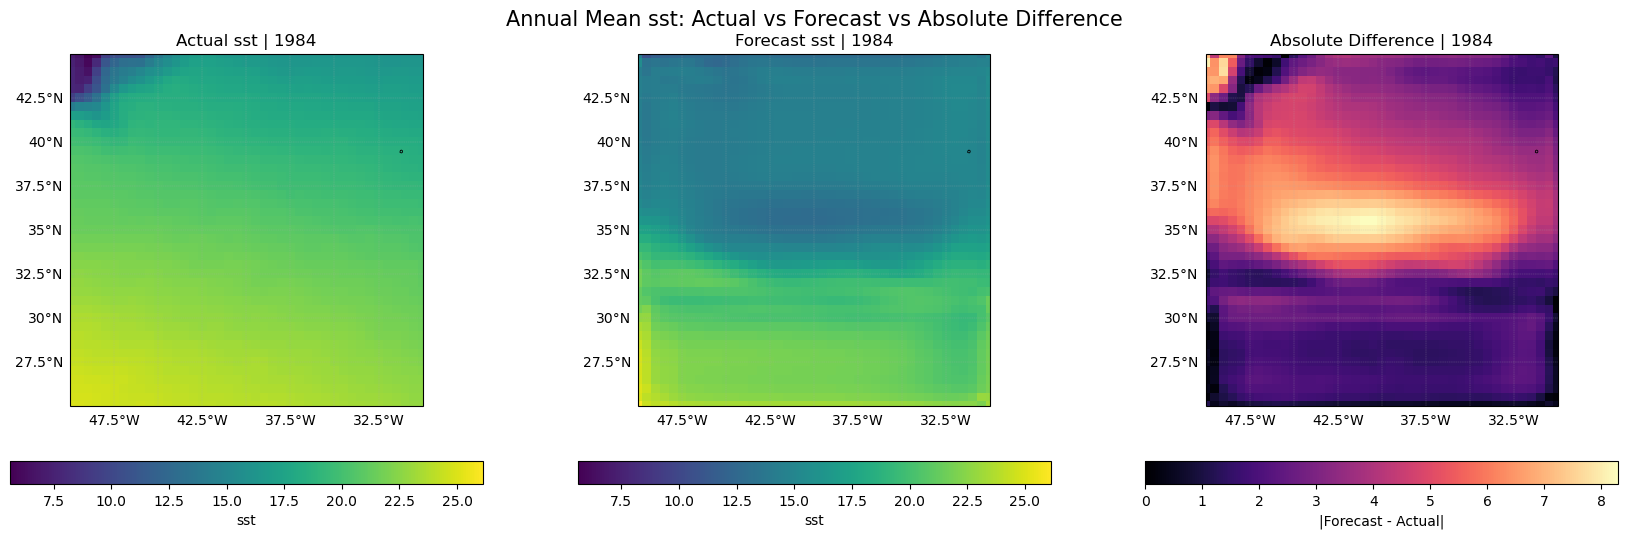

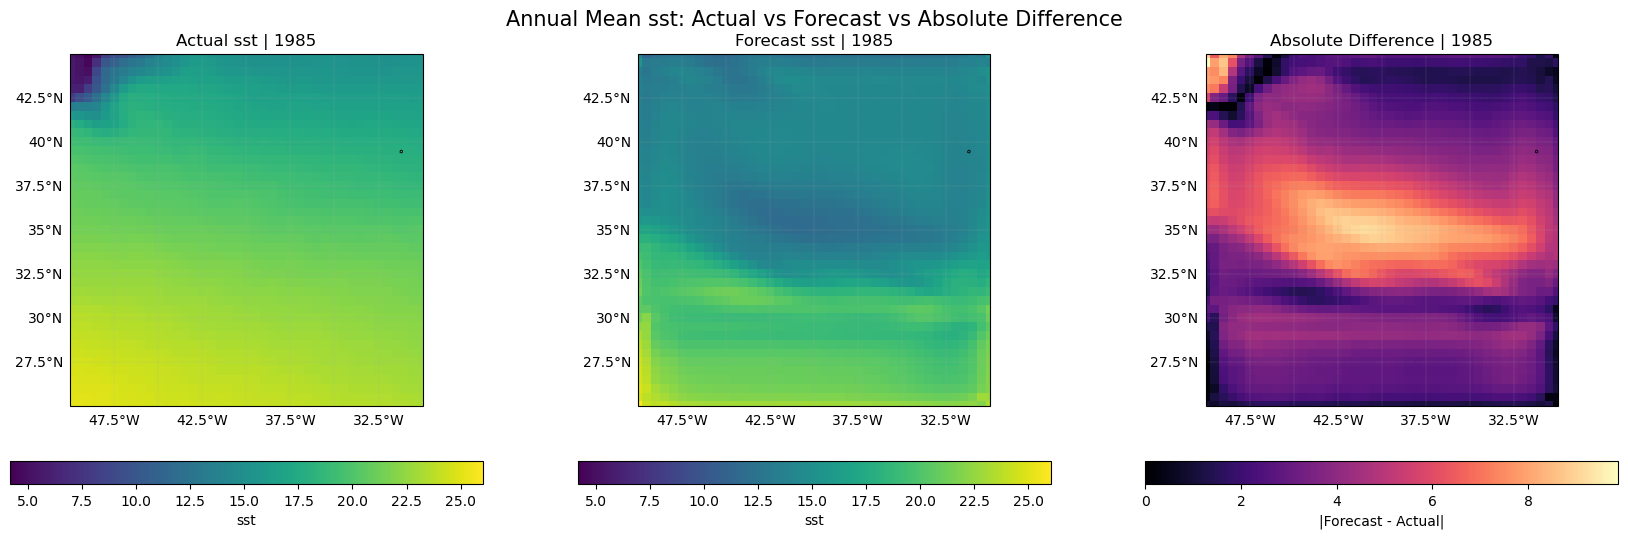

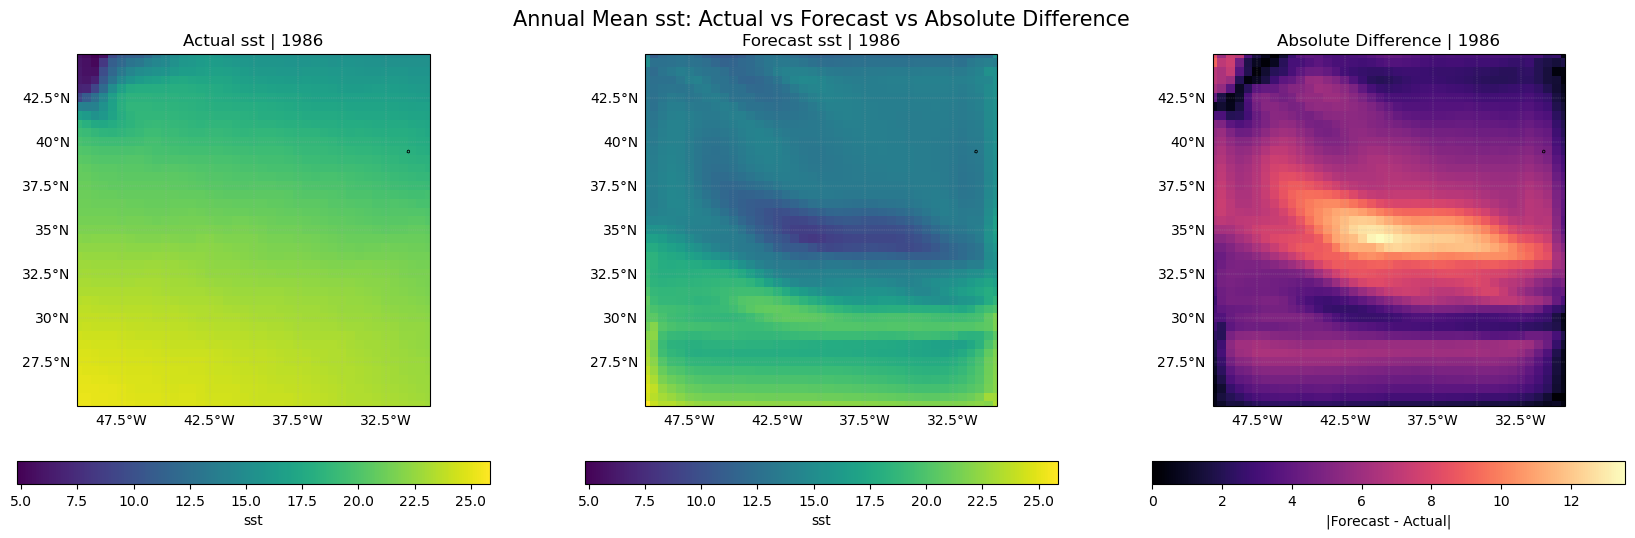

In [16]:
print(f"\n{'='*80}\n   12. ANNUAL MAPS: ACTUAL vs FORECAST vs ABSOLUTE DIFFERENCE\n{'='*80}")

import cartopy.crs as ccrs
import cartopy.feature as cfeature

feature_name = "sst"

feature_idx = scaler["features"].index(feature_name)

# Coordinates
lats = combined_monthly["lat"].values
lons = combined_monthly["lon"].values
lon2d, lat2d = np.meshgrid(lons, lats)

forecast_times = pd.to_datetime(forecast_months)

truth_mask = (times >= FORECAST_START) & (times <= FORECAST_END)
truth_period = data[truth_mask]
truth_times = pd.to_datetime(times[truth_mask])

proj = ccrs.PlateCarree()

for year in range(FORECAST_START.year, FORECAST_END.year + 1):

    actual_year_mask = truth_times.year == year
    forecast_year_mask = forecast_times.year == year

    if actual_year_mask.sum() == 0 or forecast_year_mask.sum() == 0:
        print(f"Skipping {year}: missing actual or forecast months")
        continue

    actual_map = np.nanmean(
        truth_period[actual_year_mask, :, :, feature_idx],
        axis=0
    )

    forecast_map = np.nanmean(
        forecast_unscaled[forecast_year_mask, :, :, feature_idx],
        axis=0
    )

    abs_diff = np.abs(forecast_map - actual_map)

    vmin = np.nanmin([actual_map, forecast_map])
    vmax = np.nanmax([actual_map, forecast_map])
    diff_max = np.nanmax(abs_diff)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(17, 5),
        subplot_kw={"projection": proj},
        constrained_layout=True
    )

    plot_data = [
        (actual_map, f"Actual {feature_name} | {year}", feature_name, vmin, vmax, "viridis"),
        (forecast_map, f"Forecast {feature_name} | {year}", feature_name, vmin, vmax, "viridis"),
        (abs_diff, f"Absolute Difference | {year}", f"|Forecast - Actual|", 0, diff_max, "magma"),
    ]

    for ax, (field, title, cbar_label, vmin_i, vmax_i, cmap) in zip(axes, plot_data):

        mesh = ax.pcolormesh(
            lon2d,
            lat2d,
            field,
            transform=proj,
            shading="auto",
            cmap=cmap,
            vmin=vmin_i,
            vmax=vmax_i
        )

        ax.set_extent(
            [
                REGION["lon_min"],
                REGION["lon_max"],
                REGION["lat_min"],
                REGION["lat_max"]
            ],
            crs=proj
        )

        ax.add_feature(
            cfeature.LAND,
            facecolor="lightgrey",
            edgecolor="black",
            linewidth=0.4
        )

        ax.coastlines(resolution="50m", linewidth=0.6)

        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.3,
            alpha=0.5,
            linestyle="--"
        )

        gl.top_labels = False
        gl.right_labels = False

        ax.set_title(title, fontsize=12)

        cbar = fig.colorbar(
            mesh,
            ax=ax,
            orientation="horizontal",
            pad=0.08,
            shrink=0.85
        )

        cbar.set_label(cbar_label)

    fig.suptitle(
        f"Annual Mean {feature_name}: Actual vs Forecast vs Absolute Difference",
        fontsize=15,
        y=1.04
    )

    plt.show()


   13. RELATIVE DIFFERENCE HISTOGRAMS BY YEAR


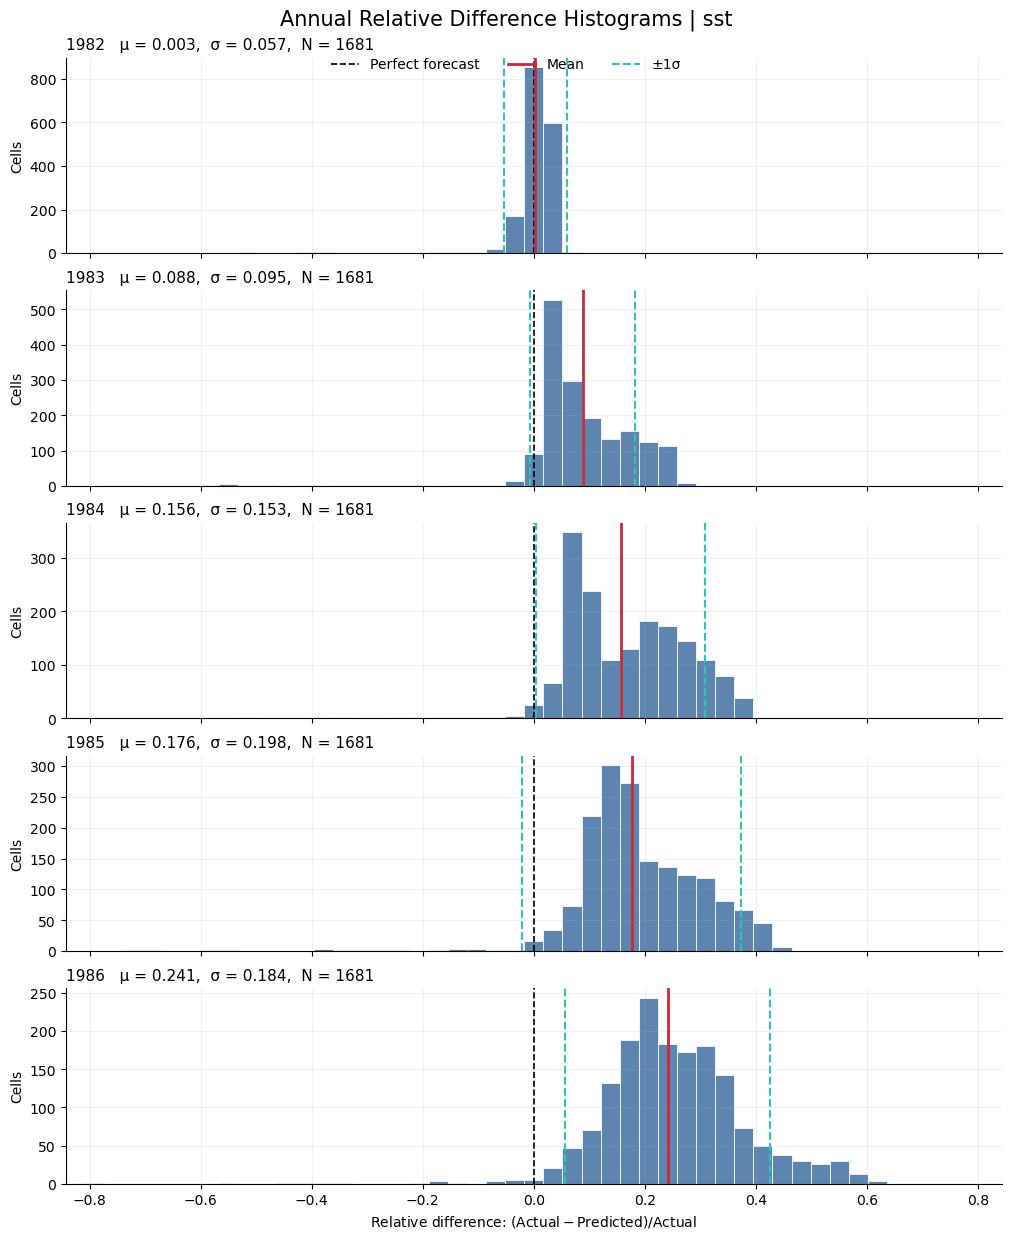

In [27]:
print(f"\n{'='*80}\n   13. RELATIVE DIFFERENCE HISTOGRAMS BY YEAR\n{'='*80}")

feature_name = "sst"
feature_idx = scaler["features"].index(feature_name)

forecast_times = pd.to_datetime(forecast_months)

truth_mask = (times >= FORECAST_START) & (times <= FORECAST_END)
truth_period = data[truth_mask]
truth_times = pd.to_datetime(times[truth_mask])

MIN_ABS_ACTUAL = 1e-6

yearly_rel_values = {}
yearly_stats = {}

for year in range(FORECAST_START.year, FORECAST_END.year + 1):

    actual_year_mask = truth_times.year == year
    forecast_year_mask = forecast_times.year == year

    actual_map = np.nanmean(
        truth_period[actual_year_mask, :, :, feature_idx],
        axis=0
    )

    forecast_map = np.nanmean(
        forecast_unscaled[forecast_year_mask, :, :, feature_idx],
        axis=0
    )

    rel_diff = (actual_map - forecast_map) / actual_map

    valid = (
        np.isfinite(rel_diff) &
        np.isfinite(actual_map) &
        (np.abs(actual_map) > MIN_ABS_ACTUAL)
    )

    rel_values = rel_diff[valid].flatten()

    yearly_rel_values[year] = rel_values
    yearly_stats[year] = {
        "mean": np.nanmean(rel_values),
        "median": np.nanmedian(rel_values),
        "sigma": np.nanstd(rel_values),
        "n": len(rel_values)
    }

# Limit x-axis
all_values = np.concatenate(list(yearly_rel_values.values()))
x_min = np.nanpercentile(all_values, 0.5)
x_max = np.nanpercentile(all_values, 99.5)

x_abs = max(abs(x_min), abs(x_max))
x_min, x_max = -x_abs, x_abs

bins = np.linspace(x_min, x_max, 50)

years = list(yearly_rel_values.keys())
n_years = len(years)

fig, axes = plt.subplots(
    n_years,
    1,
    figsize=(10, 2.4 * n_years),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

if n_years == 1:
    axes = [axes]

for ax, year in zip(axes, years):

    rel_values = yearly_rel_values[year]
    stats = yearly_stats[year]

    mean_rel = stats["mean"]
    median_rel = stats["median"]
    sigma = stats["sigma"]

    ax.hist(
        rel_values,
        bins=bins,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.6,
        alpha=0.9
    )

    # Reference lines at zero, mean, and ±1σ
    ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
    ax.axvline(mean_rel, color="#CC2936", linewidth=2.0)
    ax.axvline(mean_rel - sigma, color="#2EC4B6", linestyle="--", linewidth=1.5)
    ax.axvline(mean_rel + sigma, color="#2EC4B6", linestyle="--", linewidth=1.5)

    ax.set_title(
        f"{year}   μ = {mean_rel:.3f},  σ = {sigma:.3f},  N = {stats['n']}",
        fontsize=11,
        loc="left"
    )

    ax.set_ylabel("Cells")
    ax.grid(alpha=0.18)
    ax.set_xlim(x_min, x_max)

    # Remove visual clutter
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel(r"Relative difference: $(\mathrm{Actual}-\mathrm{Predicted})/\mathrm{Actual}$")

fig.suptitle(
    f"Annual Relative Difference Histograms | {feature_name}",
    fontsize=15,
    y=1.02
)

# Custom legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="black", linestyle="--", lw=1.2, label="Perfect forecast"),
    Line2D([0], [0], color="#CC2936", lw=2.0, label="Mean"),
    Line2D([0], [0], color="#2EC4B6", linestyle="--", lw=1.5, label="±1σ"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=3,
    frameon=False
)

plt.show()


   14. MEAN RELATIVE DIFFERENCE BY YEAR


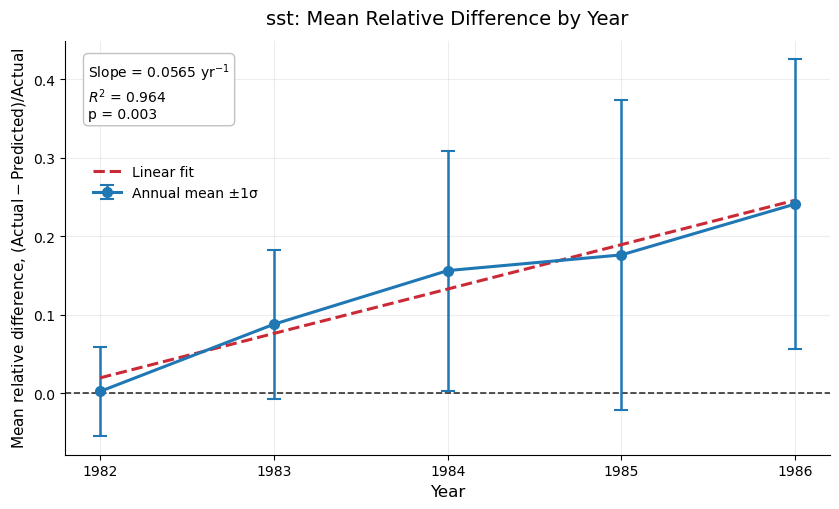

In [28]:
print(f"\n{'='*80}\n   14. MEAN RELATIVE DIFFERENCE BY YEAR\n{'='*80}")

from scipy.stats import linregress

years = np.array(sorted(yearly_stats.keys()))
means = np.array([yearly_stats[y]["mean"] for y in years])
sigmas = np.array([yearly_stats[y]["sigma"] for y in years])

slope, intercept, r_value, p_value, std_err = linregress(years, means)
fit = intercept + slope * years

fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Zero reference
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8
)

# Error bars and data line
ax.errorbar(
    years,
    means,
    yerr=sigmas,
    fmt="o-",
    color="#1f77b4",
    ecolor="#1f77b4",
    elinewidth=1.8,
    capsize=5,
    capthick=1.5,
    markersize=7,
    linewidth=2.2,
    label="Annual mean ±1σ"
)

# Linear fit
ax.plot(
    years,
    fit,
    color="#CC2936",
    linestyle="--",
    linewidth=2.2,
    label="Linear fit"
)

ax.set_title(
    f"{feature_name}: Mean Relative Difference by Year",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel(
    r"Mean relative difference, $(\mathrm{Actual}-\mathrm{Predicted})/\mathrm{Actual}$",
    fontsize=11
)

ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years])

ax.grid(alpha=0.22)

# Cleaner axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Put stats in a text box instead of the legend
stats_text = (
    f"Slope = {slope:.4f} yr$^{{-1}}$\n"
    f"$R^2$ = {r_value**2:.3f}\n"
    f"p = {p_value:.3f}"
)

ax.text(
    0.03,
    0.95,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.95
    )
)

ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.73),
    fontsize=10
)

plt.tight_layout()
plt.show()


   15. ANNUAL BOX AVERAGE SST: ACTUAL vs PREDICTED


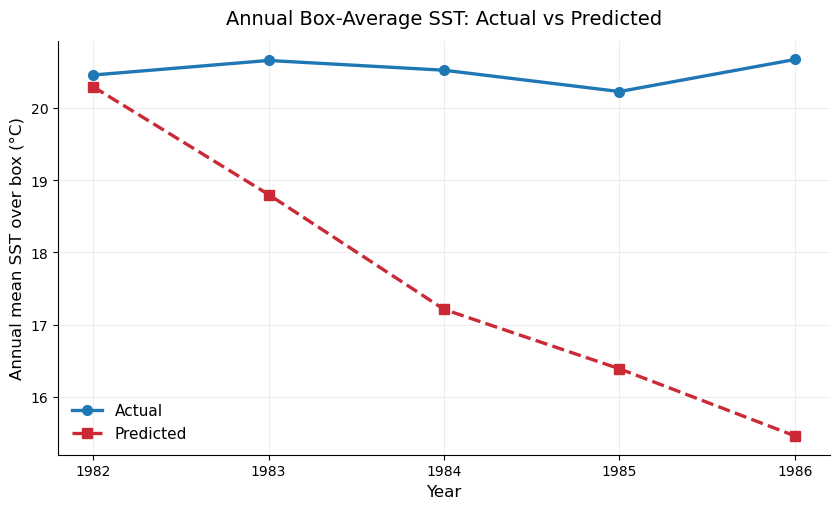

In [36]:
print(f"\n{'='*80}\n   15. ANNUAL BOX AVERAGE SST: ACTUAL vs PREDICTED\n{'='*80}")

feature_name = "sst"
feature_idx = scaler["features"].index(feature_name)

forecast_times = pd.to_datetime(forecast_months)

truth_mask = (times >= FORECAST_START) & (times <= FORECAST_END)
truth_period = data[truth_mask]
truth_times = pd.to_datetime(times[truth_mask])

years = np.arange(FORECAST_START.year, FORECAST_END.year + 1)

actual_annual_mean = []
predicted_annual_mean = []

for year in years:

    actual_year_mask = truth_times.year == year
    forecast_year_mask = forecast_times.year == year

    actual_values = truth_period[actual_year_mask, :, :, feature_idx]
    predicted_values = forecast_unscaled[forecast_year_mask, :, :, feature_idx]

    actual_annual_mean.append(np.nanmean(actual_values))
    predicted_annual_mean.append(np.nanmean(predicted_values))

actual_annual_mean = np.array(actual_annual_mean)
predicted_annual_mean = np.array(predicted_annual_mean)

fig, ax = plt.subplots(figsize=(8.5, 5.2))

ax.plot(
    years,
    actual_annual_mean,
    marker="o",
    linewidth=2.4,
    markersize=7,
    color="#1f77b4",
    label="Actual"
)

ax.plot(
    years,
    predicted_annual_mean,
    marker="s",
    linewidth=2.4,
    markersize=7,
    linestyle="--",
    color="#CC2936",
    label="Predicted"
)

ax.set_title(
    "Annual Box-Average SST: Actual vs Predicted",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual mean SST over box (°C)", fontsize=12)

ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years])

ax.grid(alpha=0.22)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=11)

stats_text = None

ax.text(
    0.03,
    0.95,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.95
    )
)

plt.tight_layout()
plt.show()


   15. ANNUAL BOX AVERAGE SST: ACTUAL vs PREDICTED


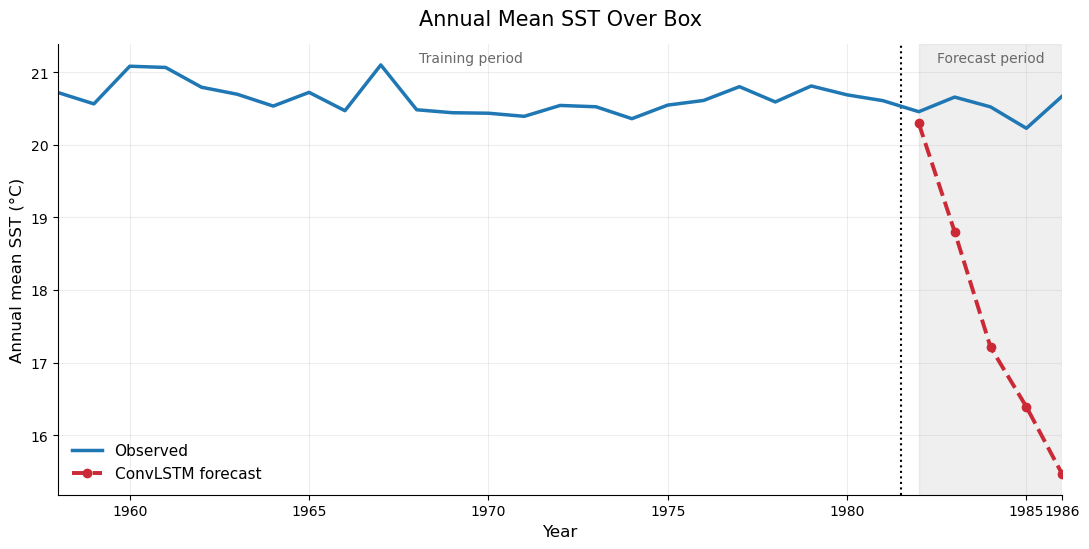

In [32]:
print(f"\n{'='*80}\n   15. ANNUAL BOX AVERAGE SST: ACTUAL vs PREDICTED\n{'='*80}")

feature_name = "sst"
feature_idx = scaler["features"].index(feature_name)

forecast_times = pd.to_datetime(forecast_months)

# Plot from start of data to end of forecast period
plot_start_year = times.min().year
plot_end_year = FORECAST_END.year

all_years = np.arange(plot_start_year, plot_end_year + 1)

actual_years = []
actual_series = []

for year in all_years:

    mask = times.year == year

    if mask.sum() == 0:
        continue

    annual_mean = np.nanmean(
        data[mask, :, :, feature_idx]
    )

    actual_years.append(year)
    actual_series.append(annual_mean)

actual_years = np.array(actual_years)
actual_series = np.array(actual_series)

# Forecast annual means
forecast_years = np.arange(
    FORECAST_START.year,
    FORECAST_END.year + 1
)

forecast_series = []

for year in forecast_years:

    mask = forecast_times.year == year

    if mask.sum() == 0:
        forecast_series.append(np.nan)
        continue

    annual_mean = np.nanmean(
        forecast_unscaled[mask, :, :, feature_idx]
    )

    forecast_series.append(annual_mean)

forecast_series = np.array(forecast_series)

# Plot
fig, ax = plt.subplots(figsize=(11, 5.6))

ax.plot(
    actual_years,
    actual_series,
    color="#1f77b4",
    linewidth=2.5,
    label="Observed",
    zorder=2
)

ax.plot(
    forecast_years,
    forecast_series,
    color="#CC2936",
    linewidth=2.8,
    linestyle="--",
    marker="o",
    markersize=6,
    label="ConvLSTM forecast",
    zorder=3
)

# Forecast period shading
ax.axvspan(
    FORECAST_START.year,
    FORECAST_END.year,
    color="grey",
    alpha=0.12,
    zorder=0
)

# Training/forecast boundary
ax.axvline(
    TRAIN_END.year + 0.5,
    color="black",
    linestyle=":",
    linewidth=1.5,
    zorder=1
)

y_top = np.nanmax(actual_series)

ax.text(
    (plot_start_year + TRAIN_END.year) / 2,
    y_top,
    "Training period",
    ha="center",
    va="bottom",
    fontsize=10,
    color="dimgray"
)

ax.text(
    (FORECAST_START.year + FORECAST_END.year) / 2,
    y_top,
    "Forecast period",
    ha="center",
    va="bottom",
    fontsize=10,
    color="dimgray"
)

ax.set_title(
    "Annual Mean SST Over Box",
    fontsize=15,
    pad=14
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual mean SST (°C)", fontsize=12)

ax.set_xlim(plot_start_year, plot_end_year)

xticks = list(np.arange(
    int(np.ceil(plot_start_year / 5) * 5),
    plot_end_year + 1,
    5
))

if plot_end_year not in xticks:
    xticks.append(plot_end_year)

ax.set_xticks(xticks)

ax.grid(alpha=0.22)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=11, loc="best")

plt.tight_layout()
plt.show()